## Parcial 2 - Steven Moreno F, 202314476

In [34]:
import numpy as np
from numpy import sin, cos
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame
import scipy
from scipy.integrate import odeint
from scipy.optimize import fsolve, least_squares, differential_evolution
from sympy import  symbols, sin , cos, lambdify

![ej1](ej1.png)

In [35]:
# Símbolos
Qx, Qy, Px, Py, k, L0, Lb = sp.symbols('Qx Qy Px Py k L0 Lb', real=True)
# Vectores
Q = sp.Matrix([Qx, Qy])
P = sp.Matrix([Px, Py])

# 1) Cinemática
R = sp.sqrt(Qx**2 + Qy**2)
theta = sp.atan2(Qy, Qx)       # ángulo polar del efector
l = R - Lb                      # extensión del telescopio

# 2) Fuerza del resorte
Delta = Q - P
Delta_norm = sp.sqrt(Delta.dot(Delta))
x_ext = Delta_norm - L0
F = -k * x_ext * (Delta / Delta_norm)   # fuerza sobre el efector

# 3) Esfuerzos generalizados por trabajo virtual
dr_dtheta = sp.Matrix([-Qy, Qx])       # = R * [-sin, cos]
dr_dl = Q / R                           # unitario radial

# Momento alrededor del origen
M_theta_vw = sp.simplify(F.dot(dr_dtheta))
M_theta_cross = sp.Matrix([Qx, Qy, 0]).cross(sp.Matrix([F[0], F[1], 0]))[2]

F_l = sp.simplify(F.dot(dr_dl))

# Sustitución numérica
subs_num = {
    Qx: 0.8, Qy: 1.3,
    Px: 1.0, Py: 1.0,
    k: 1500.0, L0: 0.2, Lb: 0.75
}

R_val = sp.N(R.subs(subs_num))
theta_val = sp.N(theta.subs(subs_num))
l_val = sp.N(l.subs(subs_num))
xext_val = sp.N(x_ext.subs(subs_num))
F_val = sp.N(F.subs(subs_num))
Mtheta1_val = sp.N(M_theta_vw.subs(subs_num))
Mtheta2_val = sp.N(M_theta_cross.subs(subs_num))
Fl_val = sp.N(F_l.subs(subs_num))

results ={
    "R_norm [m]": R_val,
    "theta [rad]": theta_val,
    "theta [deg]": sp.N(sp.deg(theta_val)),
    "l [m]": l_val,
    "Extensión resorte x [m]": xext_val,
    "F_spring_vec [N]": F_val,
    "M_theta (F·dr_dtheta) [N·m]": Mtheta1_val,
    "M_theta (r×F)_z [N·m]": Mtheta2_val,
    "F_l [N]": Fl_val,
}

display_results = "\n".join([f"{key}: {value}" for key, value in results.items()])
print(display_results)


R_norm [m]: 1.52643375224737
theta [rad]: 1.01914134426635
theta [deg]: 58.3924977537511
l [m]: 0.776433752247375
Extensión resorte x [m]: 0.160555127546399
F_spring_vec [N]: Matrix([[133.589941132431], [-200.384911698647]])
M_theta (F·dr_dtheta) [N·m]: -333.974852831078
M_theta (r×F)_z [N·m]: -333.974852831078
F_l [N]: -100.645332348101


![ej1o](ej1o.png)

![ej2](ej2.png)

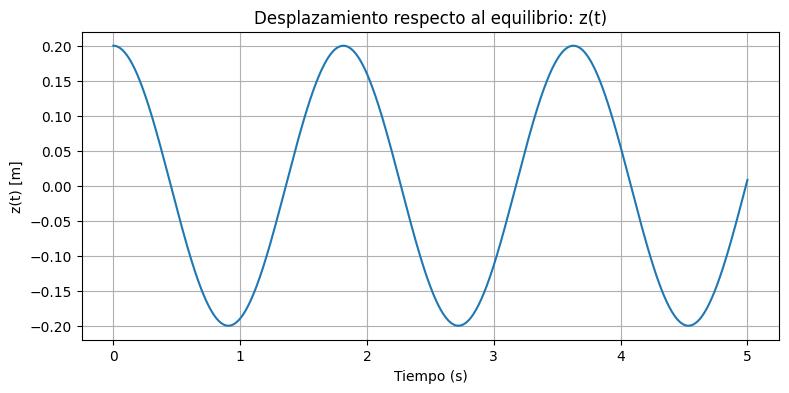

In [36]:
# Parámetros del problema
m = 0.5          # kg
mp = 1.5         # kg
R = 0.12         # m
k = 15.0         # N/m
g = 9.81         # m/s^2

# Masa equivalente y frecuencia natural
Meq = m + 0.5*mp               # = m + Jp/R^2
omega = np.sqrt(k/Meq)

# Equilibrio y CI respecto al equilibrio
x_eq = -m*g/k
z0, zd0 = 0.2, 0.0

# z(t) y derivada
def z_of_t(t):
    return z0*np.cos(omega*t) + (zd0/omega)*np.sin(omega*t)

t = np.linspace(0, 5, 1000)
z = z_of_t(t)

# Gráfica única de z(t)
plt.figure(figsize=(9,4))
plt.plot(t, z)
plt.title('Desplazamiento respecto al equilibrio: z(t)')
plt.xlabel('Tiempo (s)')
plt.ylabel('z(t) [m]')
plt.grid()
plt.show()



![ej2o](ej2o.png)

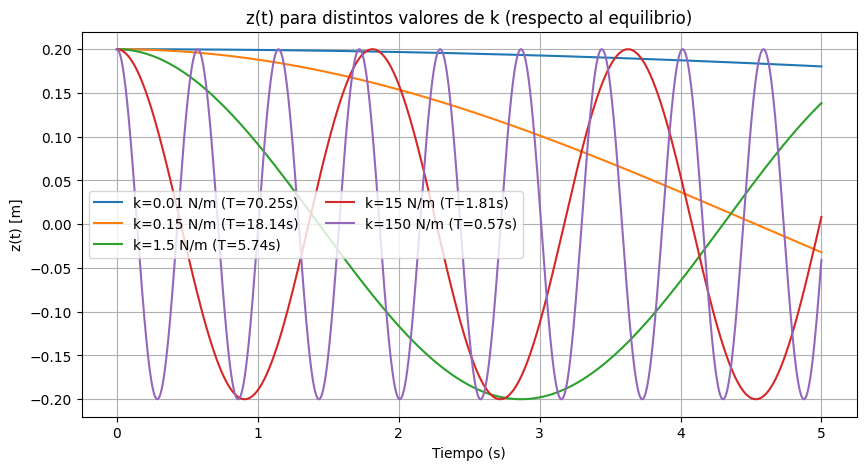

In [37]:
# Parámetros fijos del sistema
m = 0.5
mp = 1.5
Meq = m + 0.5*mp   # m + Jp/R^2
z0, zd0 = 0.2, 0.0

# Lista de rigideces
k_list = [0.01, 0.15, 1.5, 15.0, 150.0]  # N/m

# Tiempo
t = np.linspace(0, 5, 3000)

# Preparación de tabla resumen
rows = []

plt.figure(figsize=(10,5))
for k in k_list:
    omega = np.sqrt(k/Meq)
    T = 2*np.pi/omega if omega>0 else np.inf
    z = z0*np.cos(omega*t) + (zd0/omega)*np.sin(omega*t) if omega>0 else z0*np.ones_like(t)
    plt.plot(t, z, label=f'k={k:g} N/m (T={T:.2f}s)')
    rows.append({'k_N_per_m': k, 'omega_rad_s': omega, 'T_s': T})

plt.title('z(t) para distintos valores de k (respecto al equilibrio)')
plt.xlabel('Tiempo (s)')
plt.ylabel('z(t) [m]')
plt.grid()
plt.legend(ncol=2)
plt.show()

El sistema oscila como masa equivalente unida a un resorte. Su frecuencia natural resulta en la raíz de k/masa_eq y por consiguinete T =2pi/w. Por eso, al aumentar 
𝑘 (resorte más rígido) crece 𝜔 y disminuye el período: las gráficas con 𝑘=15 y 150 N/m muestran varios ciclos en 5 s, mientras que con 𝑘=0.01 o 0.15 N/m apenas se alcanza una fracción de ciclo. 

![ej3](ej3.png)

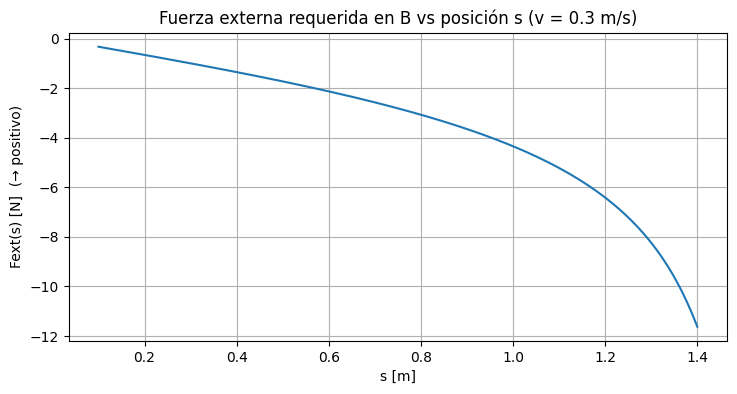

In [38]:


s = sp.symbols('s', real=True)
Lval = 1.5
mval = 1.0
gval = 9.81
sdotval = 0.3

y = sp.sqrt(Lval**2 - s**2)
Fext = (Lval**2*mval*s*sdotval**2)/(3*(Lval**2 - s**2)**2) - (gval*mval*s)/(2*y)
Fext_fun = sp.lambdify(s, Fext, 'numpy')

s_vals = np.linspace(0.1, 1.4, 300)
F_vals = Fext_fun(s_vals)

plt.figure(figsize=(8.5,4))
plt.plot(s_vals, F_vals)
plt.title('Fuerza externa requerida en B vs posición s (v = 0.3 m/s)')
plt.xlabel('s [m]')
plt.ylabel('Fext(s) [N]  (→ positivo)')
plt.grid()
plt.show()

# Valores en s=0.1 y s=1.4
F_01 = float(Fext_fun(0.1))
F_14 = float(Fext_fun(1.4))




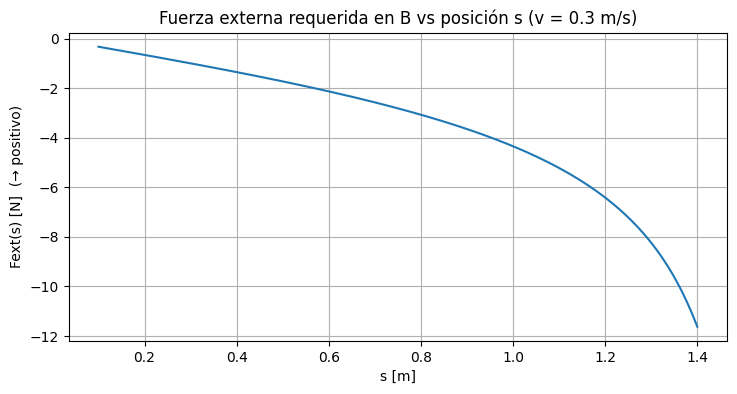

In [42]:
# Evaluación numérica con los datos del enunciado y gráfica Fext(s) para s en [0.1, 1.4]
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

s = sp.symbols('s', real=True)
Lval = 1.5
mval = 1.0
gval = 9.81
sdotval = 0.3

y = sp.sqrt(Lval**2 - s**2)
Fext = (Lval**2*mval*s*sdotval**2)/(3*(Lval**2 - s**2)**2) - (gval*mval*s)/(2*y)
Fext_fun = sp.lambdify(s, Fext, 'numpy')

s_vals = np.linspace(0.1, 1.4, 300)
F_vals = Fext_fun(s_vals)

plt.figure(figsize=(8.5,4))
plt.plot(s_vals, F_vals)
plt.title('Fuerza externa requerida en B vs posición s (v = 0.3 m/s)')
plt.xlabel('s [m]')
plt.ylabel('Fext(s) [N]  (→ positivo)')
plt.grid()
plt.show()

# Valores en s=0.1 y s=1.4
F_01 = float(Fext_fun(0.1))
F_14 = float(Fext_fun(1.4))




![ej3o](ej3o.png)

![ej4](ej4.png)

In [45]:
# Símbolos y datos
t = sp.symbols('t', real=True)
m, L, r = 43.0, 1.4, 0.22
phi = sp.rad(30)  # 30 grados en radianes

theta = 1.5*sp.exp(t) - 1.5 - t + sp.pi/2
alpha_t = sp.diff(theta, t, 2)  # aceleración angular
alpha0 = sp.N(alpha_t.subs(t, 0))  # alpha(0)

I = (1/3)*m*(L**2)                # inercia barra delgada respecto a un extremo
tau_req = I*alpha0                # par necesario en t=0
T = tau_req / (r*sp.sin(phi))     # tensión

# Mostrar resultados
{
    "alpha(0) [rad/s^2]": float(alpha0),
    "I_extremo [kg·m^2]": float(I),
    "tau_req [N·m]": float(tau_req),
    "Tension T [N]": float(T)
}


{'alpha(0) [rad/s^2]': 1.5,
 'I_extremo [kg·m^2]': 28.093333333333327,
 'tau_req [N·m]': 42.139999999999986,
 'Tension T [N]': 383.09090909090895}

![ej4o](ej4o.png)

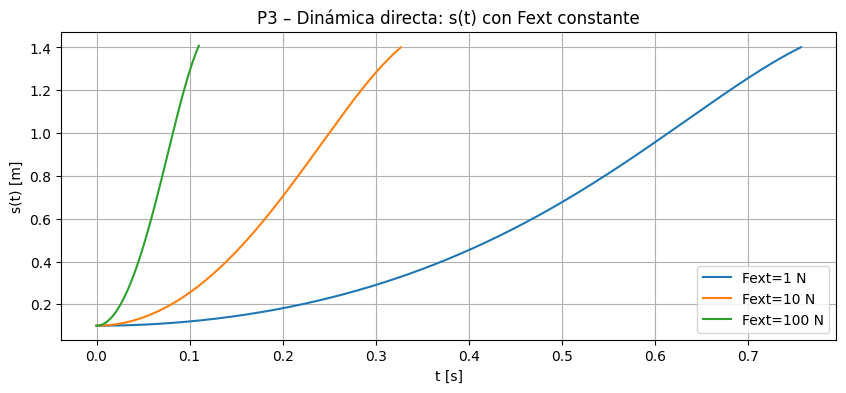

({1.0: {'s_final_m': 1.401128126872055,
   'v_final_mps': 2.1450215927947394,
   't_final_s': 0.7570000000000006},
  10.0: {'s_final_m': 1.4003463563561362,
   'v_final_mps': 3.6943297128084738,
   't_final_s': 0.32700000000000023},
  100.0: {'s_final_m': 1.4080584602459465,
   'v_final_mps': 9.833061118173694,
   't_final_s': 0.11000000000000008}},
 ['/mnt/data/p3_F1N.csv', '/mnt/data/p3_F10N.csv', '/mnt/data/p3_F100N.csv'])

<Figure size 1000x400 with 0 Axes>

In [48]:

# Parámetros del sistema
L = 1.5         # m
m = 1.0         # kg
g = 9.81        # m/s^2
I_G = (1.0/12.0)*m*(L**2)  # kg m^2

# Masa efectiva y su derivada
def M_eff(s):
    den = L**2 - s**2
    return (m/4.0)*(1.0 + (s**2)/den) + I_G/den

def dM_ds(s):
    den = L**2 - s**2
    return (2.0*m*(L**2)*s) / (3.0*(den**2))

# Aceleración s¨
def s_ddot(s, sdot, Fext):
    y = np.sqrt(max(L**2 - s**2, 1e-12))
    M  = M_eff(s)
    Mp = dM_ds(s)
    grav = m*g*s/(2.0*y)  # -dV/ds con el signo cambiado
    return (Fext + grav - 0.5*Mp*sdot**2)/M

# Integrador RK4
def integrar(Fext, t_end=5.0, dt=1e-3):
    t = [0.0]; s = [0.1]; v = [0.0]
    while t[-1] < t_end and (L**2 - s[-1]**2) > 1e-6:
        si, vi = s[-1], v[-1]

        k1v = s_ddot(si, vi, Fext);                  k1s = vi
        k2v = s_ddot(si + 0.5*dt*k1s, vi + 0.5*dt*k1v, Fext);  k2s = vi + 0.5*dt*k1v
        k3v = s_ddot(si + 0.5*dt*k2s, vi + 0.5*dt*k2v, Fext);  k3s = vi + 0.5*dt*k2v
        k4v = s_ddot(si + dt*k3s,     vi + dt*k3v,     Fext);  k4s = vi + dt*k3v

        s_new = si + (dt/6.0)*(k1s + 2*k2s + 2*k3s + k4s)
        v_new = vi + (dt/6.0)*(k1v + 2*k2v + 2*k3v + k4v)
        t_new = t[-1] + dt

        t.append(t_new); s.append(s_new); v.append(v_new)
        if s_new >= 1.4:  # corte solicitado
            break
    return np.array(t), np.array(s), np.array(v)

# Correr casos y graficar
F_list = [1.0, 10.0, 100.0]
series = {}

plt.figure(figsize=(10,4))
for F in F_list:
    tt, ss, vv = integrar(F)
    series[F] = (tt, ss, vv)
    plt.plot(tt, ss, label=f'Fext={F:g} N')
plt.title('P3 – Dinámica directa: s(t) con Fext constante')
plt.xlabel('t [s]'); plt.ylabel('s(t) [m]'); plt.grid(); plt.legend()
plt.show()

plt.figure(figsize=(10,4))


# Resumen y exportes CSV
summ = {}
for F in F_list:
    tt, ss, vv = series[F]
    summ[F] = {'s_final_m': float(ss[-1]), 'v_final_mps': float(vv[-1]), 't_final_s': float(tt[-1])}
    

summ, [f'/mnt/data/p3_F{int(F)}N.csv' for F in F_list]


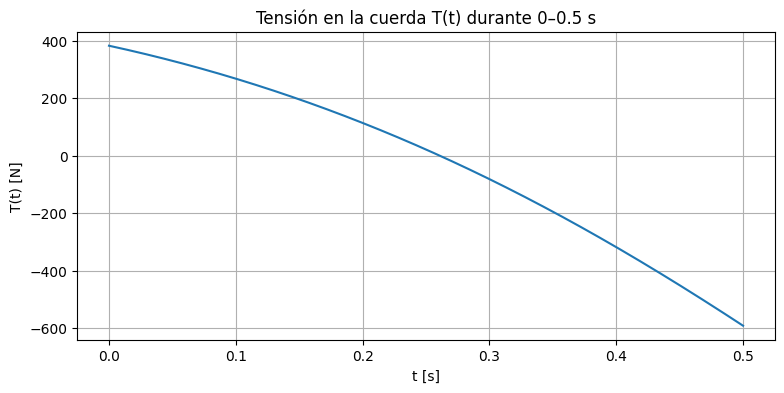

In [46]:
# Parámetros
m = 43.0
L = 1.4
r = 0.22
g = 9.81
phi = np.deg2rad(30.0)
I = (1.0/3.0) * m * L**2

# Definir θ(t), α(t)
t = sp.symbols('t', real=True)
theta = 1.5*sp.exp(t) - 1.5 - t + sp.pi/2        # rad
alpha = sp.diff(theta, t, 2)

# Funciones numéricas
theta_f = sp.lambdify(t, theta, 'numpy')
alpha_f = sp.lambdify(t, alpha, 'numpy')

# Tensión T(t)
def T_of_t(tt):
    th = theta_f(tt)
    al = alpha_f(tt)
    return (I*al + m*g*(L/2.0)*np.cos(th)) / (r*np.sin(phi))

# Malla temporal
tt = np.linspace(0.0, 0.5, 1001)
Tt = T_of_t(tt)

# Métricas y chequeos
T_min, T_max = float(np.min(Tt)), float(np.max(Tt))
t_Tmin, t_Tmax = tt[int(np.argmin(Tt))], tt[int(np.argmax(Tt))]
theta0, alpha0 = float(theta_f(0.0)), float(alpha_f(0.0))

# Graficar T(t)
plt.figure(figsize=(9,4))
plt.plot(tt, Tt)
plt.title('Tensión en la cuerda T(t) durante 0–0.5 s')
plt.xlabel('t [s]')
plt.ylabel('T(t) [N]')
plt.grid(True)
plt.show()


El torso no puede sostenerse solamente con la tensión de la cuerda en todo el recorrido. Se requerirían dos sentidos de acción: tracción (al inicio) y luego compresión (que una cuerda no puede brindar).